In [35]:
import math

# Imports from Qiskit
from qiskit import QuantumCircuit
from qiskit.circuit.library import grover_operator
from qiskit.circuit.library import MCMTGate
from qiskit.circuit.library import ZGate
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_distribution
from qiskit.visualization import plot_error_map
# Imports from Qiskit Runtime
from qiskit_ibm_runtime import fake_provider
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [11]:
#backend = fake_provider.FakeBrisbane() # large one
backend = fake_provider.FakeBelemV2() # small one

In [12]:
print(f'{backend.name}: {backend.description}')

fake_belem: 5 qubit device Belem


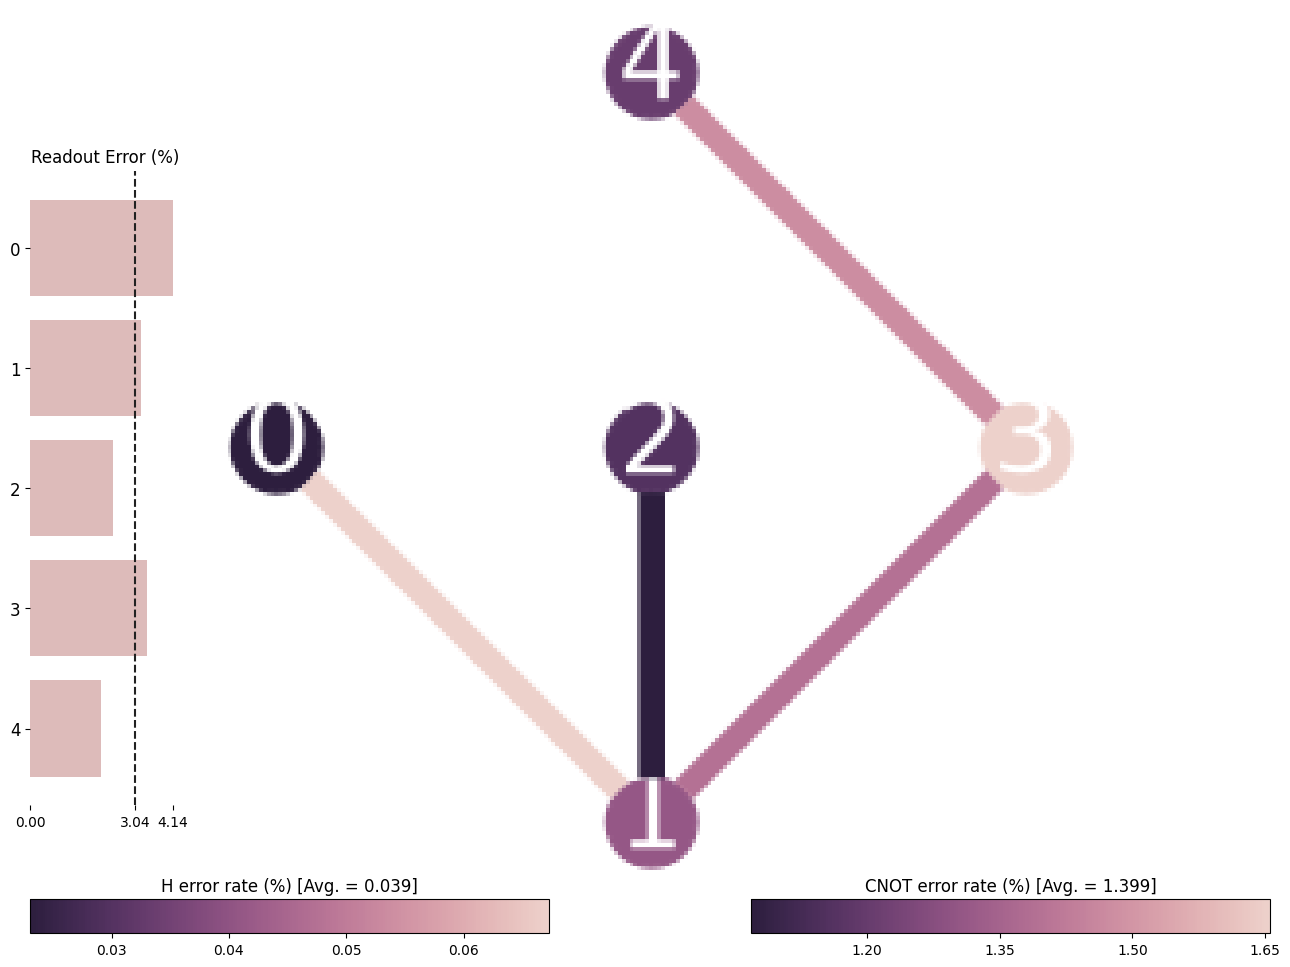

In [13]:
plot_error_map(backend, figsize=(16, 12), show_title=False)

In [22]:
def build_grover_oracle(marked_state_list: list[str]) -> QuantumCircuit:
    # Compute the number of qubits in circuit
    num_qubits = len(marked_state_list[0])

    qc = QuantumCircuit(num_qubits)
    # Mark each target state in the input list
    for marked_state in marked_state_list:
        # Qiskit reads bit-strings right-to-left (qubit 0 is the rightmost bit),
        # so we reverse the string to align with Qiskit's bit-ordering convention.
        rev_target = marked_state[::-1]

        # The trick for marking an arbitrary state |b_n...b_1 b_0>:
        # A multi-controlled Z gate naturally flips the phase only of |11...1>.
        # To mark a *different* state, we wrap the gate in X gates on every qubit
        # whose target bit is '0'. The X gates temporarily turn 0s into 1s,
        # the MCZ flips the phase, and then we undo the X gates.
        zero_index_list = [index for index, element in enumerate(rev_target) if element == '0']

        # Step (a): Apply X to qubits where the marked state has a '0'.
        if len(zero_index_list) > 0:
            qc.x(zero_index_list)

        # Step (b): Apply a multi-controlled Z gate.
        # With (num_qubits - 1) control qubits and 1 target, this flips the phase
        # of |11...1> only — which now corresponds to our chosen marked state.
        qc.compose(MCMTGate(gate=ZGate(), num_ctrl_qubits=(num_qubits - 1), num_target_qubits=1), inplace=True)

        # Step (c): Undo the X gates so the qubits return to the computational basis.
        if len(zero_index_list) > 0:
            qc.x(zero_index_list)
    return qc

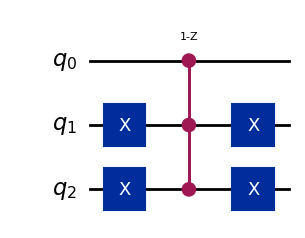

In [23]:
# We're searching for the state "001" out of the 8 possible 3-qubit states
# (000, 001, 010, ..., 111). Classically you'd check each one in turn — Grover
# finds it in fewer steps using quantum interference.
marked_states = ["001"]

oracle = build_grover_oracle(marked_states)
oracle.draw(output="mpl", style="iqp")

In [ ]:
# The Grover operator = (oracle) followed by the "diffuser" (also called the
# inversion-about-the-mean operator). Together, one application of this operator
# slightly increases the amplitude of the marked state and decreases the others.
# qiskit.circuit.library.grover_operator builds this combo for us.
grover_op = grover_operator(oracle)

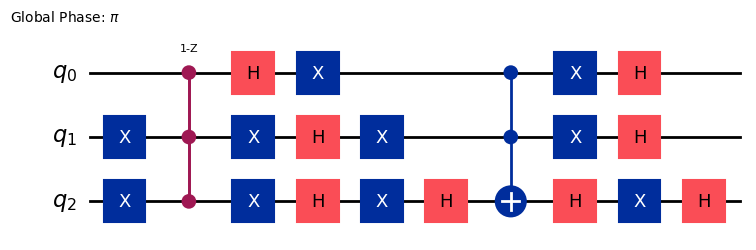

In [24]:
grover_op.draw(output="mpl", style="iqp")

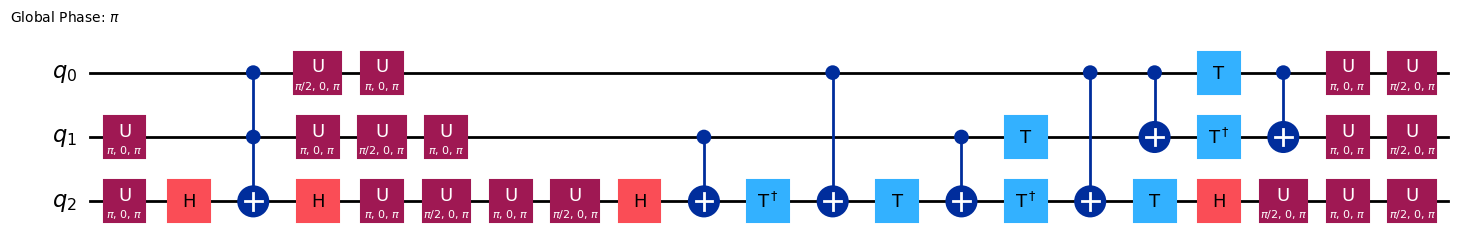

In [16]:
grover_op.decompose().draw(output="mpl", style="iqp")

In [17]:
optimal_num_iterations = math.floor(
    math.pi
    / (4 * math.asin(math.sqrt(len(marked_states) / 2**grover_op.num_qubits)))
)

print(f'{optimal_num_iterations=}')

optimal_num_iterations=2


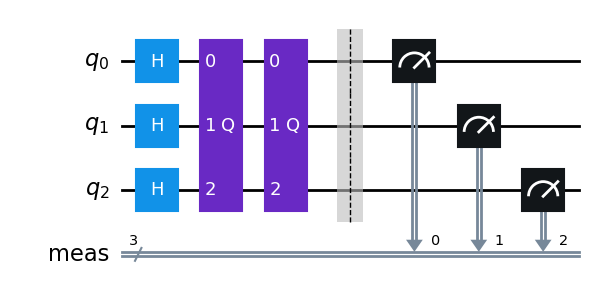

In [25]:
qc = QuantumCircuit(grover_op.num_qubits)

# (a) Create an even superposition over all 2^n basis states by applying a
#     Hadamard (H) gate to every qubit. After this, every state is equally likely.
qc.h(range(grover_op.num_qubits))

# (b) Apply the Grover operator the optimal number of times.
#     .power(k) means "repeat this operator k times."
qc.compose(grover_op.power(optimal_num_iterations), inplace=True)

# (c) Measure all qubits. This collapses the quantum state into a classical
#     bit-string, which is what we read out as the result.
qc.measure_all()

qc.draw(output="mpl", style='textbook')

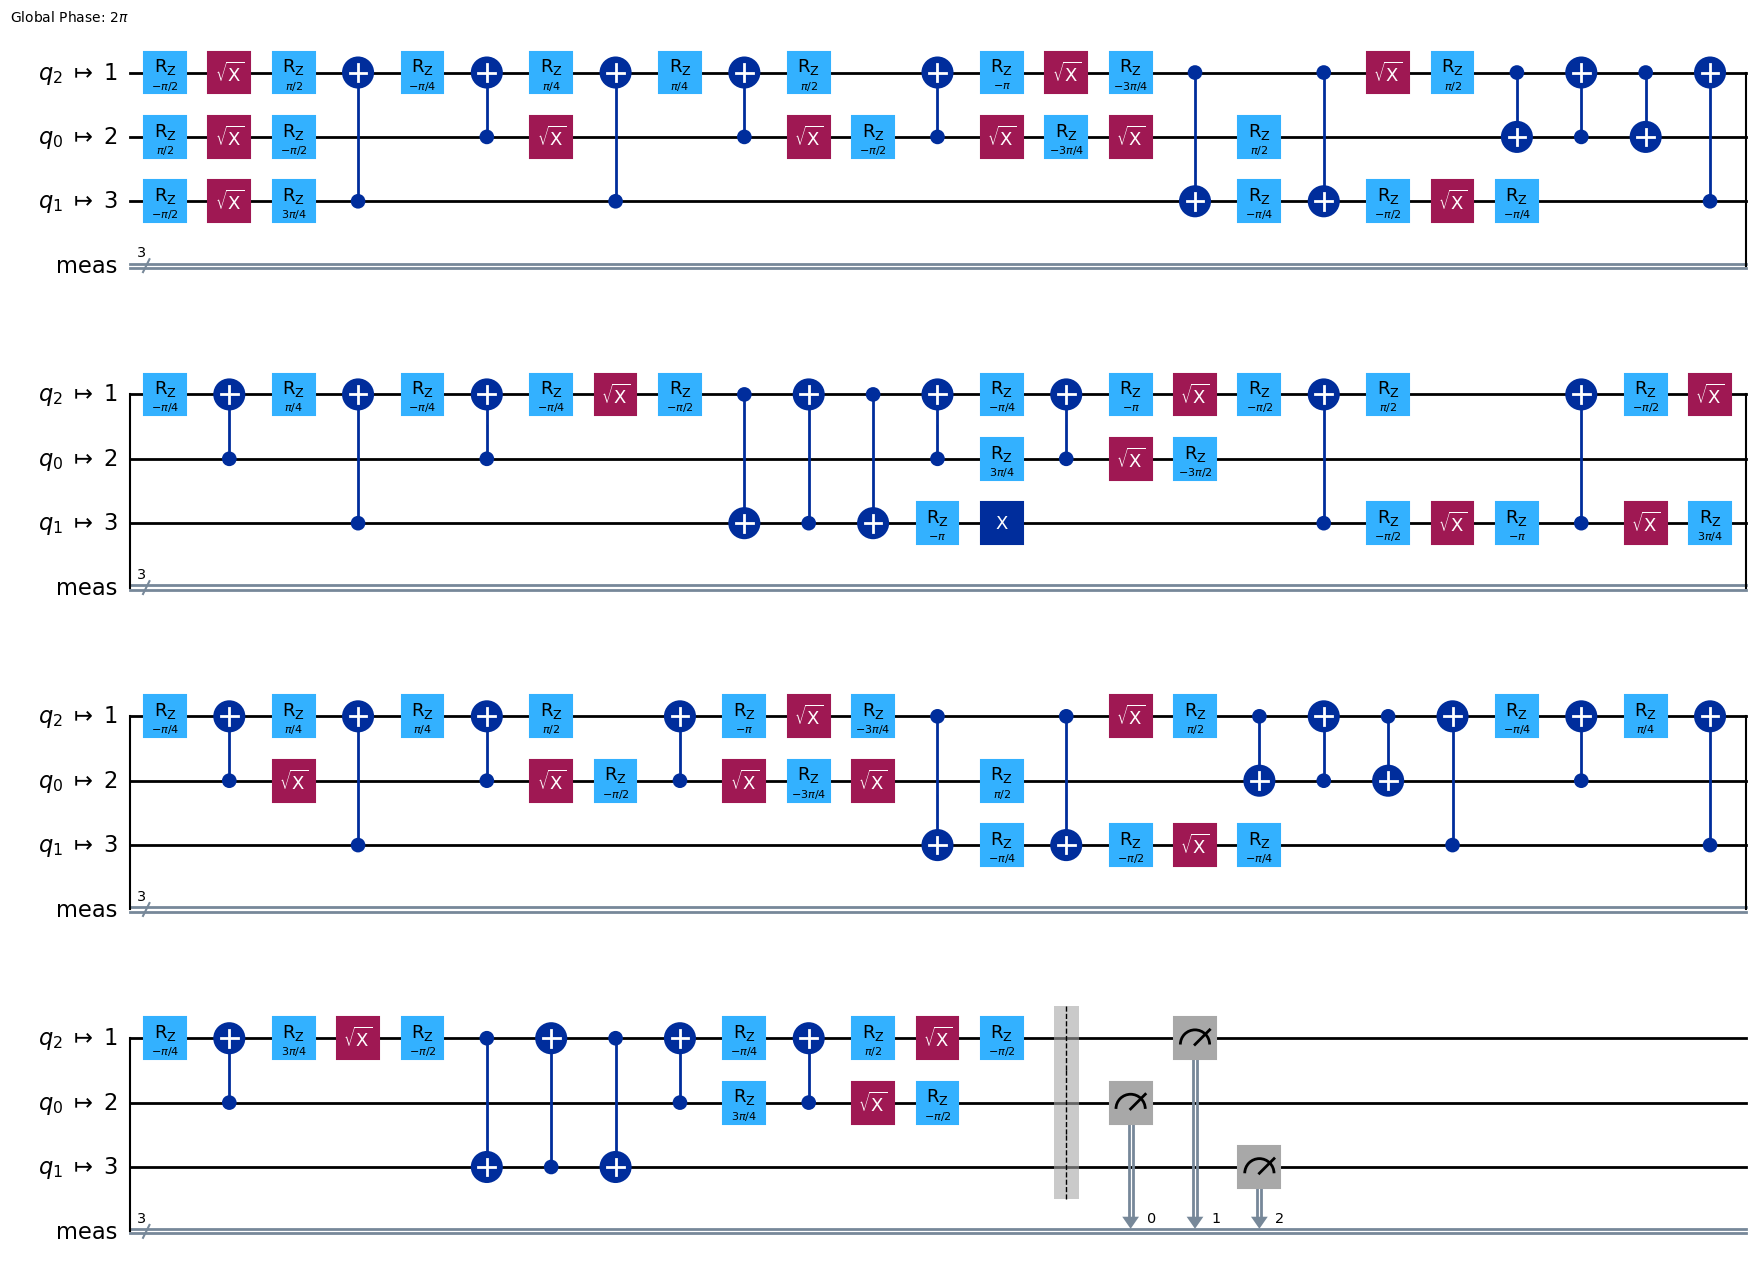

In [26]:
target = backend.target
pass_manager = generate_preset_pass_manager(target=target, optimization_level=3)

# ISA: Backend's Instruction Set Architecture (ISA)
circuit_isa = pm.pass_manager(qc)
circuit_isa.draw(output="mpl", idle_wires=False, style="iqp")

In [36]:
simulator = AerSimulator.from_backend(backend)

In [40]:
# Run the circuit 1e5 times and store individual measurement outcomes
job = simulator.run(circuit_isa, shots=10_000, memory=True)

In [41]:
# Retrieve the simulation result
result = job.result()

In [46]:
counts = result.get_counts()

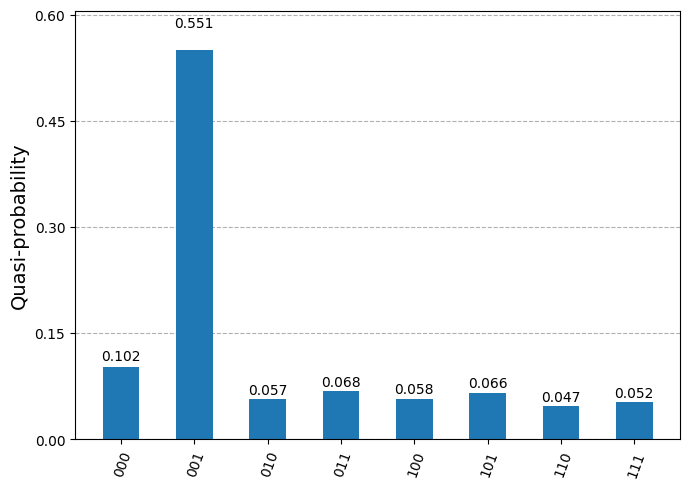

In [47]:
plot_distribution(dist)